In [85]:
using AlgebraicOptimization
using Catlab
using Plots
using ForwardDiff

In [97]:
A = rand(2, 2)
A = A' * A
b = rand(2)

B = rand(2, 2)
B = B' * B
c = rand(2)

C = rand(2, 2)
C = C' * C
d = rand(2)

f(x) = x' * A * x - b' * x
g(y) = y' * B * y - c' * y
h(z) = z' * C * z - d' * z

hole_obj = z -> f(z[1:2]) + g(z[2:3]) + h([z[3],z[1]])
filled_obj = z -> f(z[1:2]) + g([z[1],z[3]]) + h([z[1],z[4]])

using Optim

res1 = optimize(hole_obj, zeros(3), LBFGS(), Optim.Options(store_trace=true); autodiff = :forward)
res2 = optimize(filled_obj, zeros(4), LBFGS(), Optim.Options(store_trace=true); autodiff = :forward)

println(Optim.converged(res1))
println(Optim.converged(res2))

true
true


In [98]:
sol1 = Optim.minimizer(res1)
sol2 = Optim.minimizer(res2)

println(hole_obj(sol1))
println(filled_obj(sol2))

-0.36363336522578743
-4.590313813863414


In [99]:
using LinearAlgebra

function relative_error_func(x_true)
    x -> norm(x - x_true) / norm(x_true)
end

err1 = relative_error_func(sol1)
err2 = relative_error_func(sol2)

#67 (generic function with 1 method)

In [100]:
function gradient_descent(p::Function, niters, ss, x0)
    traj = [x0]
    for _ in 1:niters
        x_curr = traj[end]
        x_up = x_curr - ss*ForwardDiff.gradient(p, x_curr)
        push!(traj, x_up)
    end
    return traj
end

gradient_descent (generic function with 2 methods)

In [101]:
t1 = gradient_descent(hole_obj, 1000, 0.001, [100.0,100,100])
t2 = gradient_descent(filled_obj, 1000, 0.001, [100,100.0,100,100]);

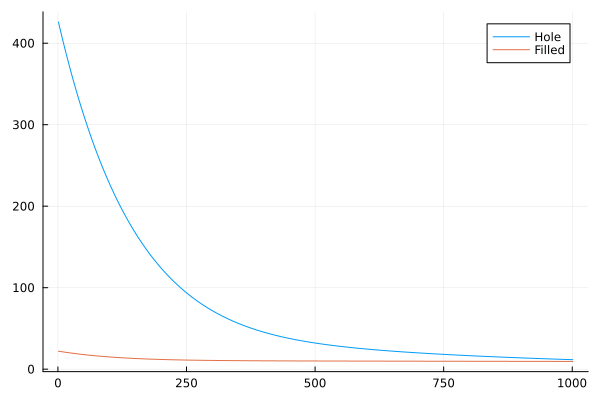

In [102]:
plot(err1.(t1), label="Hole")
plot!(err2.(t2), label="Filled")

In [109]:
err1(t1[651])

22.08580682309926

In [103]:
err2(t2[1])

22.073565917678852

In [110]:
x0_hole = t1[651]

3-element Vector{Float64}:
  4.178465328869895
 -4.1523297558841525
  7.146072226822159

In [113]:
t1_2 = gradient_descent(hole_obj, 1000, 0.1, x0_hole)
t2_2 = gradient_descent(filled_obj, 1000, 0.1, [100,100.0,100,100]);


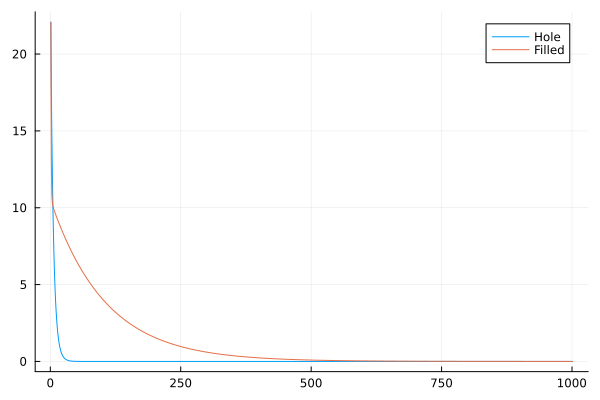

In [114]:
plot(err1.(t1_2), label="Hole")
plot!(err2.(t2_2), label="Filled")

In [115]:
err1(t1_2[end])

3.8239913407581215e-16

In [116]:
err2(t2_2[end])

0.0007509748230233188